In [257]:
# attempt to match the psf before scaling

In [258]:
from astropy.io import fits
import numpy as np

oiii_data = np.asarray(fits.open("images/normalized_OIII.fits")[0].data, dtype=np.float32)
oiiic_data = np.asarray(fits.open("images/aligned_normalized_OIIIC.fits")[0].data, dtype=np.float32)

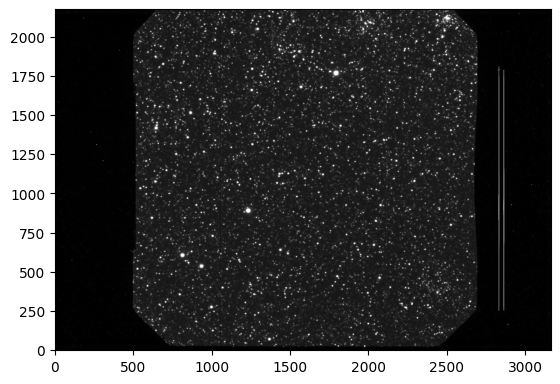

In [261]:
import matplotlib.pyplot as plt

oiiic_crop = oiiic_data
plt.imshow(oiiic_crop, cmap='gray', origin='lower', vmin=np.percentile(oiiic_crop,1), vmax=np.percentile(oiiic_crop,99.5))
plt.show()


# 1790, 1765 was too bright
# try 1035, 1102

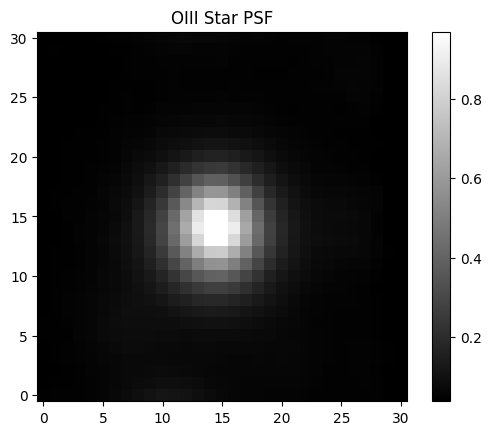

In [262]:
from astropy.nddata import Cutout2D

size = 31
star_oiii = Cutout2D(oiii_data, (1035, 1102), (size, size)).data
plt.imshow(star_oiii, origin="lower", cmap="gray", vmin=np.nanpercentile(star_oiii, 5), vmax=np.nanpercentile(star_oiii, 99.5))
plt.colorbar()
plt.title("OIII Star PSF")
plt.show()

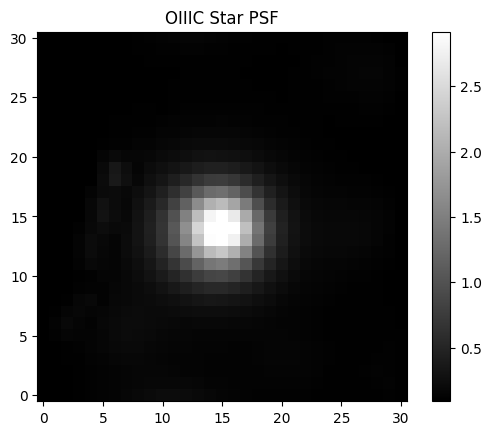

In [263]:
from astropy.nddata import Cutout2D

size = 31
star_oiiic = Cutout2D(oiiic_data, (1035, 1102), (size, size)).data
plt.imshow(star_oiiic, origin="lower", cmap="gray", vmin=np.nanpercentile(star_oiiic, 5), vmax=np.nanpercentile(star_oiiic, 99.5))
plt.colorbar()
plt.title("OIIIC Star PSF")
plt.show()

In [264]:
# OIII PSF
psf_oiii = star_oiii - np.nanmedian(star_oiii)
# psf_oiii[psf_oiii < 0] = 0    # reject negative values
psf_oiii = psf_oiii / np.nansum(psf_oiii)  # normalize

In [265]:
# OIII PSF
psf_oiiic = star_oiiic - np.nanmedian(star_oiiic)
# psf_oiiic[psf_oiiic < 0] = 0    # reject negative values
psf_oiiic = psf_oiiic / np.nansum(psf_oiiic)  # normalize

In [266]:
from photutils.psf import fit_fwhm

fwhm_oiii = fit_fwhm(star_oiii)
fwhm_oiiic = fit_fwhm(star_oiiic)

print("OIII FWHM:", fwhm_oiii)
print("OIIIC FWHM:", fwhm_oiiic)

OIII FWHM: [7.68522008]
OIIIC FWHM: [6.36362861]


In [267]:
# from photutils.psf_matching import make_kernel
# kernel = make_kernel(psf_oiii, psf_oiiic)

from photutils.psf_matching import make_kernel, CosineBellWindow

window = CosineBellWindow(alpha=0.5)
kernel = make_kernel(psf_oiiic, psf_oiii, window=window)

(31, 31)
1.0


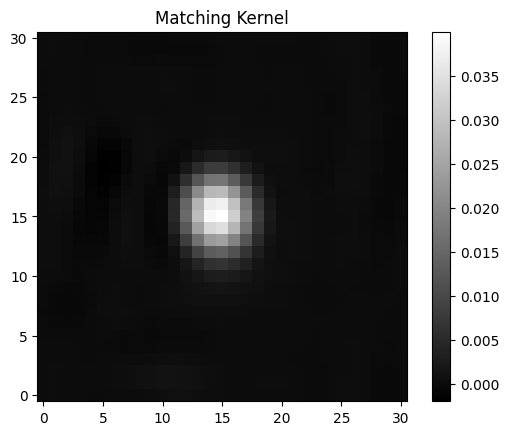

In [268]:
import matplotlib.pyplot as plt

print(kernel.shape)
print(kernel.sum())

plt.imshow(kernel, origin="lower", cmap="gray")
plt.colorbar()
plt.title("Matching Kernel")
plt.show()

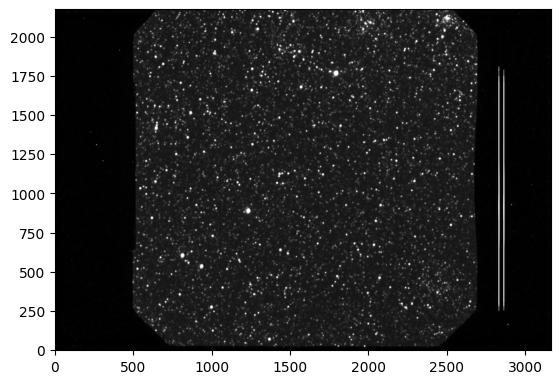

In [269]:
# blur OIII data to match OIIIC data using astropy convolution

from astropy.convolution import convolve_fft
oiiic_convolved = convolve_fft(oiiic_data, kernel, normalize_kernel=True, allow_huge=True)

plt.imshow(oiiic_convolved, cmap='gray', origin='lower', vmin=np.percentile(oiiic_convolved,1), vmax=np.percentile(oiiic_convolved,99.5))
plt.show()

In [271]:
from astropy.nddata import Cutout2D
from photutils.psf import fit_fwhm

x, y = 1035, 1102
size = 31

# Original stars
star_oiii = Cutout2D(oiii_data, (x, y), (size, size)).data
star_oiiic = Cutout2D(oiiic_data, (x, y), (size, size)).data

# Convolved star
star_oiiic_conv = Cutout2D(oiiic_convolved, (x, y), (size, size)).data

# Measure FWHM
fwhm_oiii = fit_fwhm(star_oiii)
fwhm_oiiic = fit_fwhm(star_oiiic)
fwhm_conv = fit_fwhm(star_oiiic_conv)

print(f"OIII FWHM: {fwhm_oiii[0]:.3f}")
print(f"OIIIC FWHM: {fwhm_oiiic[0]:.3f}")
print(f"Convolved OIIIC FWHM: {fwhm_conv[0]:.3f}")

OIII FWHM: 7.685
OIIIC FWHM: 6.364
Convolved OIIIC FWHM: 9.146


In [273]:
# detect stars in oiii
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder

oiii_crop = oiii_data[1000:2000, 750:1750]
mean, median, std = sigma_clipped_stats(oiii_crop, sigma=3.0)


daofind = DAOStarFinder(fwhm=10, threshold=20*std, sharplo=0.3,sharphi=1.0,roundlo=-0.5,roundhi=0.5)
sources = daofind(oiii_crop - median)

print("Number of stars found:", len(sources))
print(sources["xcentroid", "ycentroid", "flux", "peak"][:10])

Number of stars found: 378
    x_centroid         y_centroid        flux      peak   
------------------ ------------------ --------- ----------
161.01898126566692 3.6789527559042603  6.461212  0.1409588
 929.0487559888379  5.749887168608387 48.893387  1.0669975
 530.3600421363902  8.323480726747452 11.085011 0.18898432
 607.8532280528046 12.382446933407131 12.525662 0.27890986
 82.75113945545705  13.76254801889657 15.501826 0.35071906
 645.0366140530377 15.646426112877176 3.9327457 0.08669114
 414.7493536589898   16.7617924495992 14.490276 0.33747444
188.87393746744866 20.906208540633298 16.935207 0.38947988
359.35470599437195 21.683413735267315 20.262302 0.42479786
 675.1811995685604 26.168983043119923 11.439964 0.19207084


In [275]:
# import matplotlib.pyplot as plt
# from photutils.aperture import CircularAperture

positions = np.transpose((sources["xcentroid"], sources["ycentroid"]))
# apertures = CircularAperture(positions, r=8)

# plt.imshow(oiii_crop, cmap='gray', origin='lower', vmin=np.percentile(oiii_crop,1), vmax=np.percentile(oiii_crop,99.5))
# apertures.plot(color="red", lw=1.5, alpha=0.7)
# plt.show()

from photutils.aperture import CircularAperture, aperture_photometry
import numpy as np

# positions = star positions, same coordinates in both aligned images
apertures = CircularAperture(positions, r=8)

phot_oiii = aperture_photometry(oiii_data, apertures)
phot_oiiic = aperture_photometry(oiiic_data, apertures)

flux_oiii = np.array(phot_oiii["aperture_sum"])
flux_oiiic = np.array(phot_oiiic["aperture_sum"])

ratios = flux_oiii / flux_oiiic

# reject weird stars/outliers
good = np.isfinite(ratios)
ratios = ratios[good]

scale = np.median(ratios)

print("Continuum scale =", scale)

Continuum scale = 0.42006724657389916


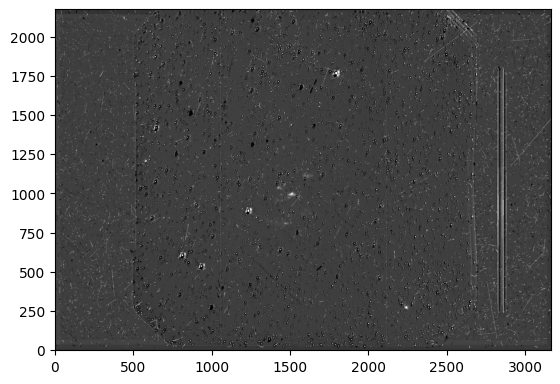

In [276]:
subtracted = oiii_data - oiiic_convolved * 0.42

plt.imshow(subtracted, cmap='gray', origin='lower', vmin=np.percentile(subtracted,1), vmax=np.percentile(subtracted,99.5))
plt.show()

fits.writeto("test_sub.fits", subtracted, overwrite=True)